In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from warnings import filterwarnings
filterwarnings('ignore')

In [89]:
df = pd.read_excel('flight-data.xlsx')

In [90]:
df.shape

(10683, 11)

In [91]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


### Columns
- Numerical - price(Target column)
- Categorical -

In [93]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [94]:
df.duplicated().sum()

np.int64(220)

# Univariate Analysis

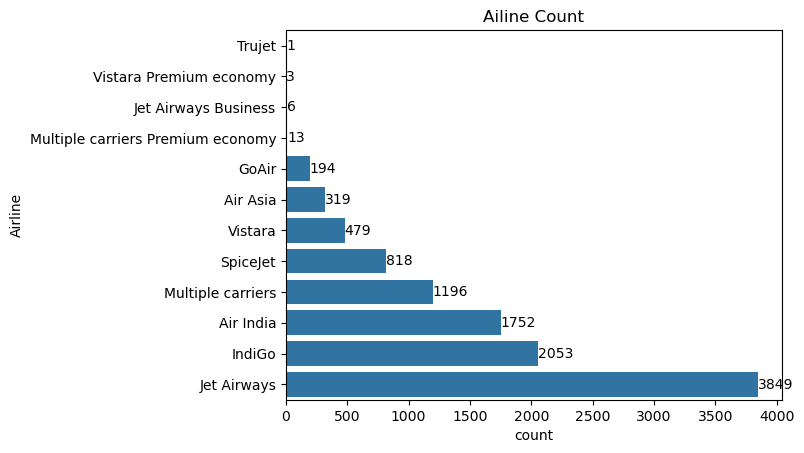

In [95]:
ax = sns.countplot(y=df['Airline'], order=df['Airline'].value_counts().sort_values(ascending=True).index)
ax.bar_label(ax.containers[0])
plt.title("Ailine Count")
plt.show()

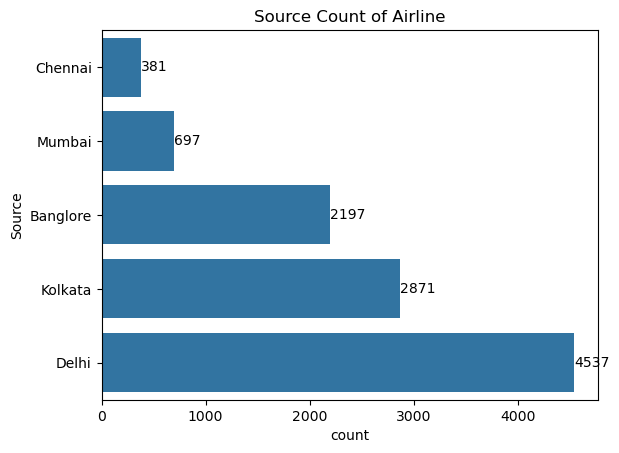

In [96]:
ax = sns.countplot(y=df['Source'], order=df['Source'].value_counts().sort_values(ascending=True).index)
ax.bar_label(ax.containers[0])
plt.title("Source Count of Airline")
plt.show()

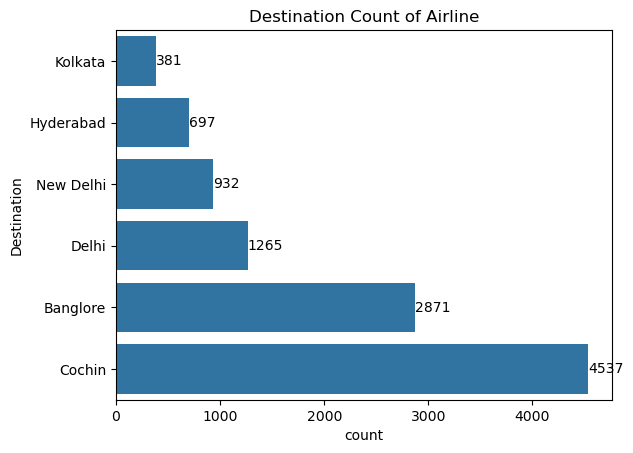

In [97]:
ax = sns.countplot(y=df['Destination'], order=df['Destination'].value_counts().sort_values(ascending=True).index)
ax.bar_label(ax.containers[0])
plt.title("Destination Count of Airline")
plt.show()

In [98]:
df['Route'].value_counts()

Route
DEL → BOM → COK          2376
BLR → DEL                1552
CCU → BOM → BLR           979
CCU → BLR                 724
BOM → HYD                 621
                         ... 
CCU → VTZ → BLR             1
CCU → IXZ → MAA → BLR       1
BOM → COK → MAA → HYD       1
BOM → CCU → HYD             1
BOM → BBI → HYD             1
Name: count, Length: 128, dtype: int64

In [99]:
df['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

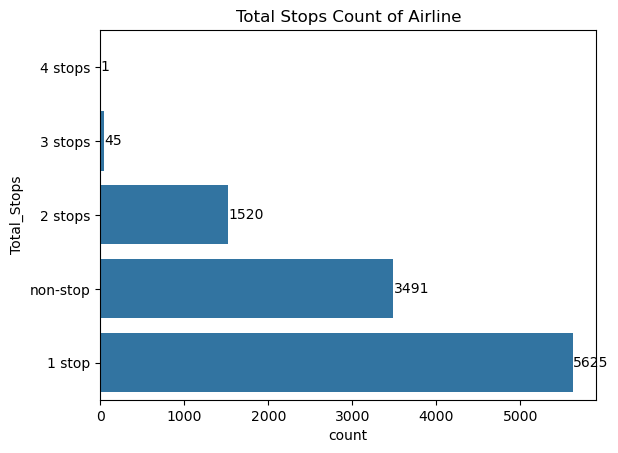

In [100]:
ax = sns.countplot(y=df['Total_Stops'], order=df['Total_Stops'].value_counts().sort_values(ascending=True).index)
ax.bar_label(ax.containers[0])
plt.title("Total Stops Count of Airline")
plt.show()

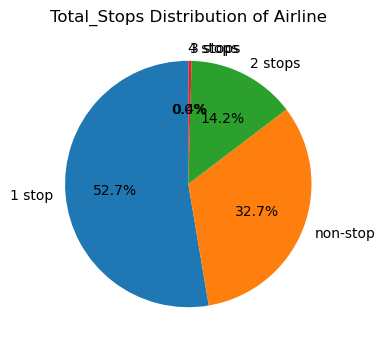

In [101]:
plt.figure(figsize=(4,4))

counts = df['Total_Stops'].value_counts()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Total_Stops Distribution of Airline")
plt.show()

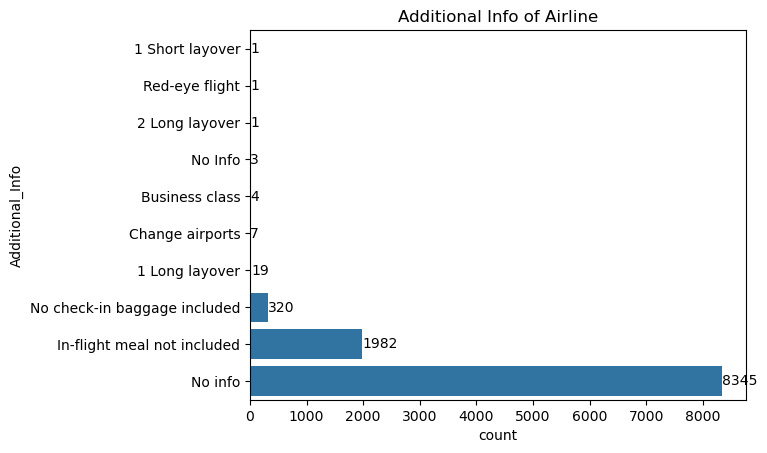

In [102]:
ax = sns.countplot(y=df['Additional_Info'], order=df['Additional_Info'].value_counts().sort_values(ascending=True).index)
ax.bar_label(ax.containers[0])
plt.title("Additional Info of Airline")
plt.show()

### Price
- Mean Price is 9087
- Price is highly Right Skewed

<Axes: xlabel='Price', ylabel='Count'>

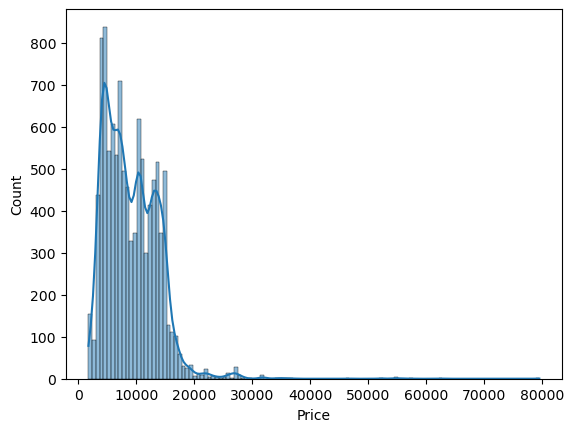

In [103]:
sns.histplot(df['Price'], kde=True)

<Axes: ylabel='Price'>

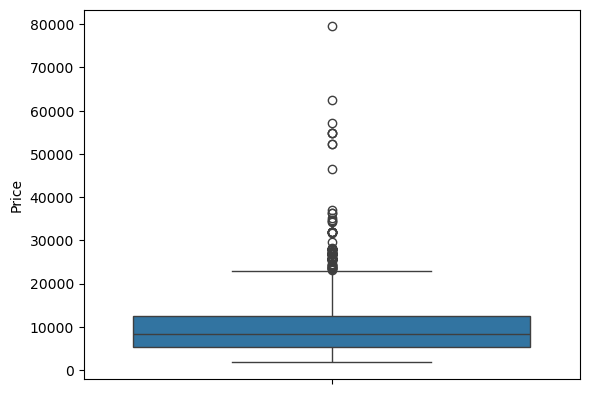

In [104]:
sns.boxplot(df['Price'])

In [105]:
df['Price'].mean()

np.float64(9087.064120565385)

# Bivariate Analysis

- Airline: 'Jet Airways Business' are paid highest prices.
- Source: 'Delhi', 'Kolkata', 'Bangloure' Are paid more flight prices.
- Destination: 'New Delhi', 'Cochin', 'Banglore' Are paid more flight prices.
- Total_stops: More stop passengers paid more flight prices.
- Aditional_info: 'No information' status passegers Are high but their prices are very low.

In [106]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [107]:
df[df['Airline']=='Jet Airways Business']['Price'].mean()

np.float64(58358.666666666664)

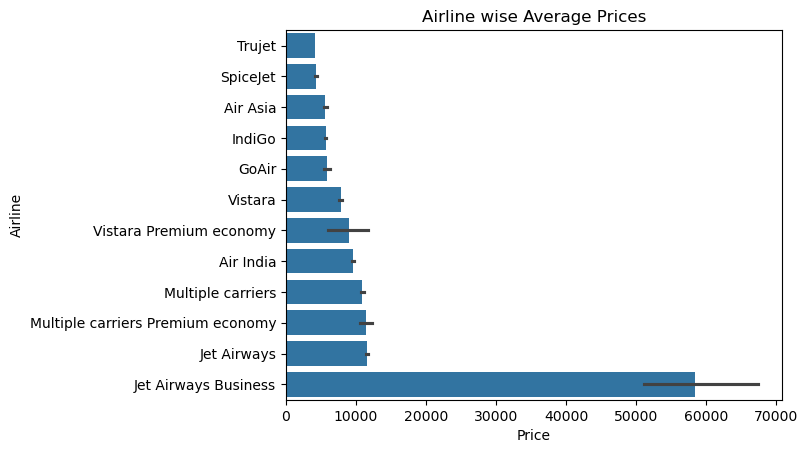

In [108]:
order = df.groupby('Airline')['Price'].mean().sort_values(ascending=True).index
sns.barplot(y='Airline', x='Price', data=df, order=order)
plt.title("Airline wise Average Prices")
plt.show()

In [109]:
order = df.groupby('Source')['Price'].mean().sort_values(ascending=True).index
order

Index(['Chennai', 'Mumbai', 'Banglore', 'Kolkata', 'Delhi'], dtype='object', name='Source')

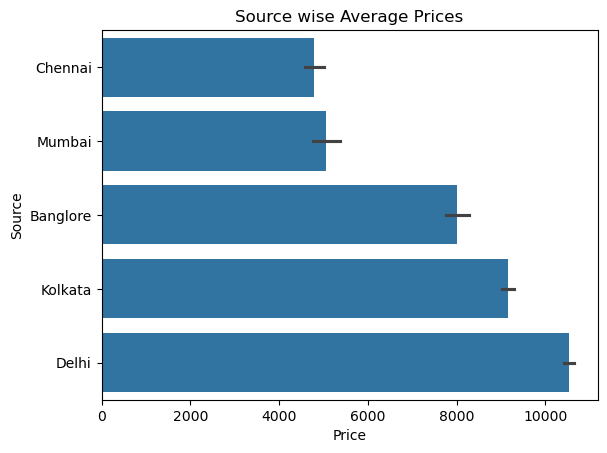

In [110]:
order = df.groupby('Source')['Price'].mean().sort_values(ascending=True).index
sns.barplot(y='Source', x='Price', data=df, order=order)
plt.title("Source wise Average Prices")
plt.show()

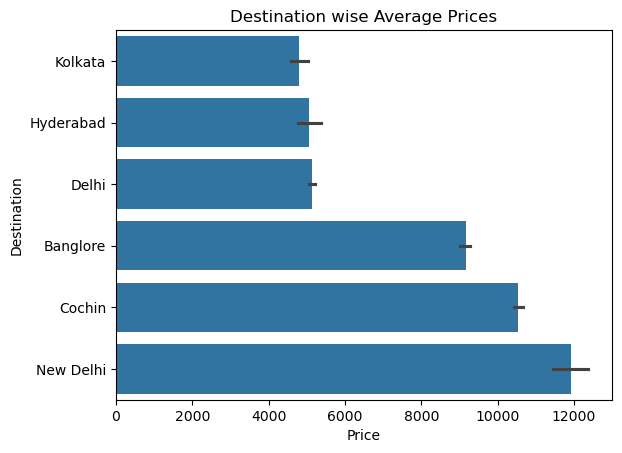

In [111]:
order = df.groupby('Destination')['Price'].mean().sort_values(ascending=True).index
sns.barplot(y='Destination', x='Price', data=df, order=order)
plt.title("Destination wise Average Prices")
plt.show()

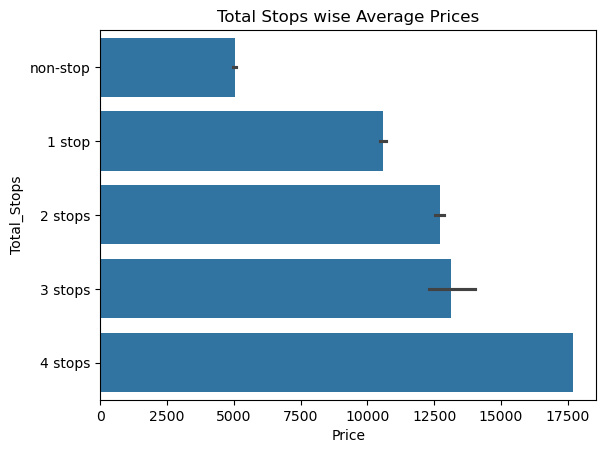

In [112]:
order = df.groupby('Total_Stops')['Price'].mean().sort_values(ascending=True).index
sns.barplot(y='Total_Stops', x='Price', data=df, order=order)
plt.title("Total Stops wise Average Prices")
plt.show()

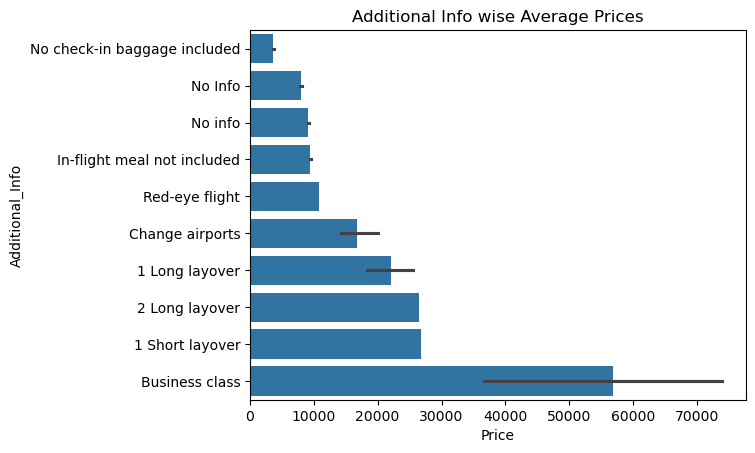

In [113]:
order = df.groupby('Additional_Info')['Price'].mean().sort_values(ascending=True).index
sns.barplot(y='Additional_Info', x='Price', data=df, order=order)
plt.title("Additional Info wise Average Prices")
plt.show()

# Feature Engineering

In [114]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [116]:
df.isna().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [117]:
df.dropna(inplace=True)

In [118]:
df.loc[df['Airline'] == 'Jet Airways Business', 'Additional_Info'] = 'Business class'

In [119]:
df.loc[df['Additional_Info'] == 'No Info', 'Additional_Info'] = 'No info'

In [120]:
df[df['Airline']=='Jet Airways Business']['Additional_Info']

657      Business class
2924     Business class
5372     Business class
7351     Business class
9715     Business class
10364    Business class
Name: Additional_Info, dtype: object

In [121]:
df['Total_Stops'] = df['Total_Stops'].str.replace('stops','').str.replace('stop','').str.replace('non-','0').str.strip()

In [122]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])

In [123]:
df['Duration'].value_counts()

Duration
2h 50m     550
1h 30m     386
2h 45m     337
2h 55m     337
2h 35m     329
          ... 
31h 30m      1
30h 25m      1
42h 5m       1
4h 10m       1
47h 40m      1
Name: count, Length: 368, dtype: int64

In [124]:
def convert_duration(x):
    h, m = 0, 0
    if 'h' in x:
        h = int(x.split('h')[0])
    if 'm' in x:
        m = int(x.split('m')[-2].split()[-1])
    return h*60 + m

df['Duration_in_min'] = df['Duration'].apply(convert_duration)

In [125]:
df['Duration_in_min'].info()

<class 'pandas.core.series.Series'>
Index: 10682 entries, 0 to 10682
Series name: Duration_in_min
Non-Null Count  Dtype
--------------  -----
10682 non-null  int64
dtypes: int64(1)
memory usage: 166.9 KB


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Route            10682 non-null  object        
 5   Dep_Time         10682 non-null  datetime64[ns]
 6   Arrival_Time     10682 non-null  datetime64[ns]
 7   Duration         10682 non-null  object        
 8   Total_Stops      10682 non-null  object        
 9   Additional_Info  10682 non-null  object        
 10  Price            10682 non-null  int64         
 11  Duration_in_min  10682 non-null  int64         
dtypes: datetime64[ns](3), int64(2), object(7)
memory usage: 1.1+ MB


In [127]:
df['Date_of_Journey'].dt.month_name().value_counts()

Date_of_Journey
May      3465
June     3414
March    2724
April    1079
Name: count, dtype: int64

In [128]:
df['Date_of_Journey'].dt.year.value_counts()

Date_of_Journey
2019    10682
Name: count, dtype: int64

In [129]:
df['Month_of_the_Journey'] = df['Date_of_Journey'].dt.month_name()

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Airline               10682 non-null  object        
 1   Date_of_Journey       10682 non-null  datetime64[ns]
 2   Source                10682 non-null  object        
 3   Destination           10682 non-null  object        
 4   Route                 10682 non-null  object        
 5   Dep_Time              10682 non-null  datetime64[ns]
 6   Arrival_Time          10682 non-null  datetime64[ns]
 7   Duration              10682 non-null  object        
 8   Total_Stops           10682 non-null  object        
 9   Additional_Info       10682 non-null  object        
 10  Price                 10682 non-null  int64         
 11  Duration_in_min       10682 non-null  int64         
 12  Month_of_the_Journey  10682 non-null  object        
dtypes: datetime64[ns](3),

In [131]:
df.sample(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_in_min,Month_of_the_Journey
9247,Jet Airways,2019-03-03,Delhi,Cochin,DEL → IDR → BOM → COK,2026-05-17 05:25:00,2026-03-04 18:50:00,37h 25m,2,No info,20064,2245,March
7705,IndiGo,2019-05-21,Delhi,Cochin,DEL → MAA → COK,2026-05-17 07:15:00,2026-05-17 12:30:00,5h 15m,1,No info,5636,315,May


In [132]:
df.drop_duplicates(inplace=True)

In [133]:
df.shape

(10462, 13)

# Univariate Analysis
- Most of the Airlines are Jet Airways, Indigo, AirIndia[71%]
- Most of the Flights are running from Delhi->Cochin[41.5%]
- Most of the people prefer to travel in 1 stops(53.77%) and 0 stops(33.22%)
- Most of the Flights have no additonal Information(78.21%)
- Most of the Flight are run in May(32.45%) and June(31.65%) months
- Most of the Peoples(33.20%) are likely to Travel 75 to 195 mins
- Most of the Peoples(97.41%) are likely to Travel in Price less then 17261

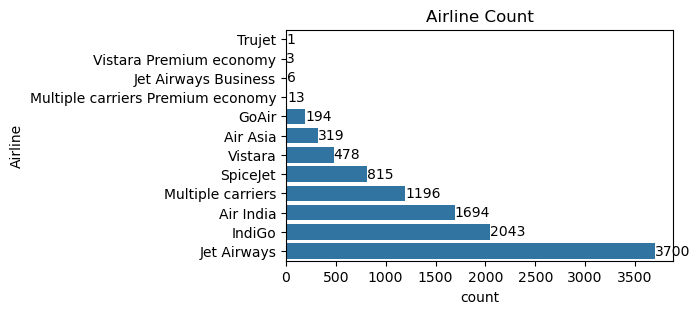

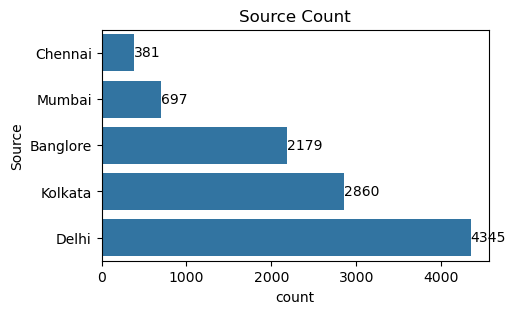

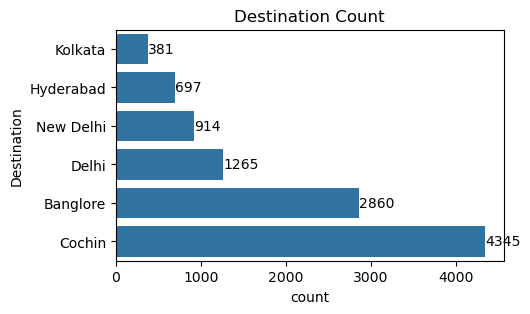

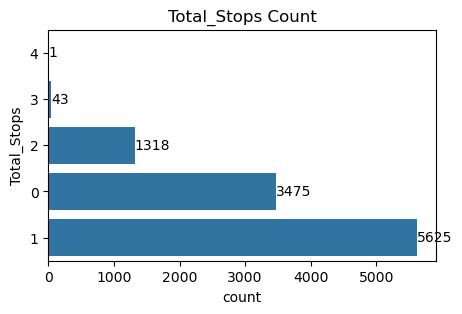

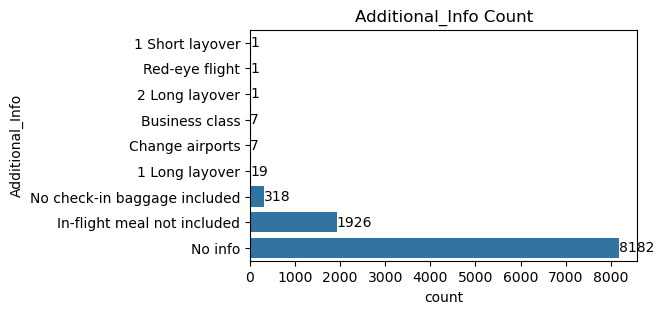

In [134]:
for col in ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info']:
    plt.figure(figsize=(5,3))
    ax = sns.countplot(y=df[col], order=df[col].value_counts().sort_values().index)
    ax.bar_label(ax.containers[0])
    plt.title(f"{col} Count")
    plt.show()
    print()

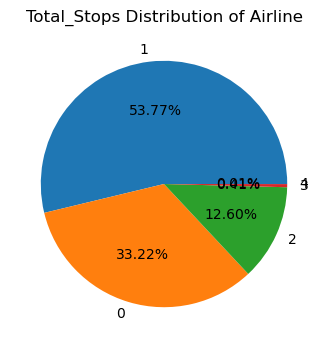

In [135]:
plt.figure(figsize=(4,4))
plt.pie(df['Total_Stops'].value_counts(), autopct='%1.2f%%', labels=df['Total_Stops'].value_counts().index)
plt.title("Total_Stops Distribution of Airline")
plt.show()

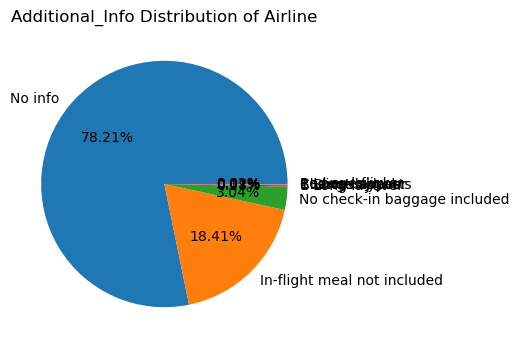

In [136]:
plt.figure(figsize=(4,4))
plt.pie(df['Additional_Info'].value_counts(), autopct='%1.2f%%', labels=df['Additional_Info'].value_counts().index)
plt.title("Additional_Info Distribution of Airline")
plt.show()

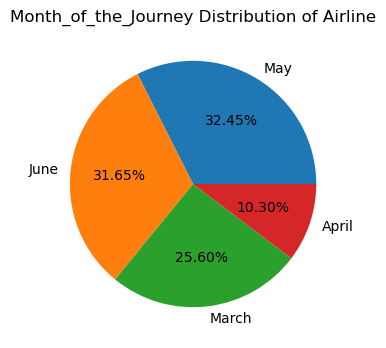

In [137]:
plt.figure(figsize=(4,4))
plt.pie(df['Month_of_the_Journey'].value_counts(), autopct='%1.2f%%', labels=df['Month_of_the_Journey'].value_counts().index)
plt.title("Month_of_the_Journey Distribution of Airline")
plt.show()

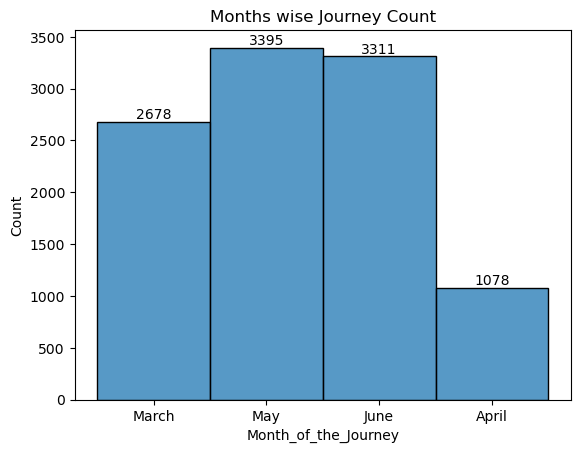

In [138]:
ax = sns.histplot(df['Month_of_the_Journey'])
ax.bar_label(ax.containers[0])
plt.title("Months wise Journey Count")
plt.show()

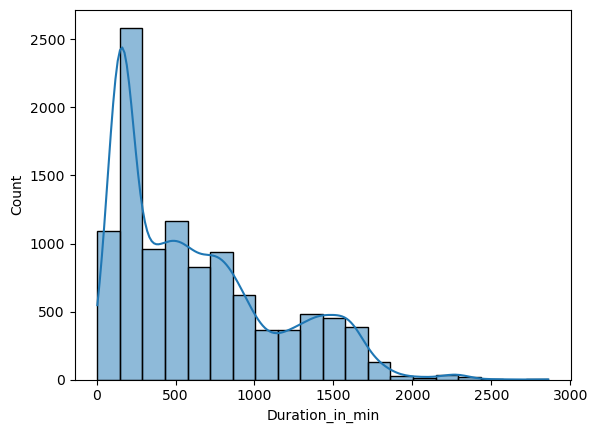

In [139]:
sns.histplot(df['Duration_in_min'], bins=20, kde=True)
plt.show()

In [140]:
df['Duration_in_min'].skew()

np.float64(0.9039730204553534)

In [141]:
df[(df['Duration_in_min']>=75) & (df['Duration_in_min']<=195)]['Airline'].count()/len(df)*100

np.float64(33.20588797553049)

In [142]:
# for duration, count in df['Duration_in_min'].value_counts().sort_index().items():
#   print(f"{duration} min -> {count}")

<Axes: xlabel='Price', ylabel='Count'>

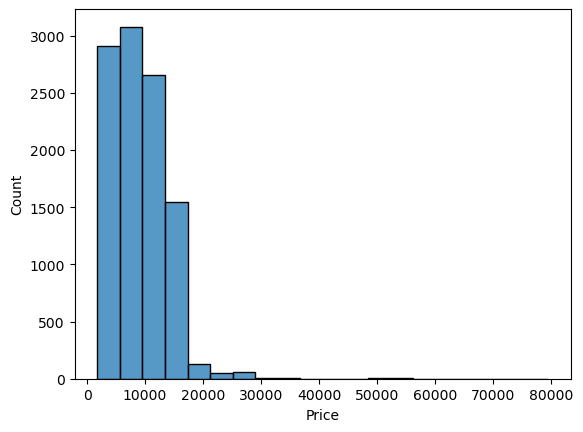

In [143]:
sns.histplot(df['Price'], bins=20)

In [144]:
counts, bin_edges = np.histogram(df['Price'], bins=20)

for i in range(len(counts)):
    print(f"Bin {i+1}: {bin_edges[i]:.2f}  to  {bin_edges[i+1]:.2f}  → Count = {counts[i]}")

Bin 1: 1759.00  to  5646.65  → Count = 2913
Bin 2: 5646.65  to  9534.30  → Count = 3079
Bin 3: 9534.30  to  13421.95  → Count = 2657
Bin 4: 13421.95  to  17309.60  → Count = 1550
Bin 5: 17309.60  to  21197.25  → Count = 131
Bin 6: 21197.25  to  25084.90  → Count = 50
Bin 7: 25084.90  to  28972.55  → Count = 57
Bin 8: 28972.55  to  32860.20  → Count = 9
Bin 9: 32860.20  to  36747.85  → Count = 6
Bin 10: 36747.85  to  40635.50  → Count = 1
Bin 11: 40635.50  to  44523.15  → Count = 0
Bin 12: 44523.15  to  48410.80  → Count = 1
Bin 13: 48410.80  to  52298.45  → Count = 2
Bin 14: 52298.45  to  56186.10  → Count = 3
Bin 15: 56186.10  to  60073.75  → Count = 1
Bin 16: 60073.75  to  63961.40  → Count = 1
Bin 17: 63961.40  to  67849.05  → Count = 0
Bin 18: 67849.05  to  71736.70  → Count = 0
Bin 19: 71736.70  to  75624.35  → Count = 0
Bin 20: 75624.35  to  79512.00  → Count = 1


In [145]:
# for Price, count in df['Price'].value_counts().sort_index().items():
#   print(f"{Price} rs -> {count}")

In [146]:
df[df['Price']<=17261]['Airline'].count()/len(df)*100

np.float64(97.41923150449246)

<Axes: ylabel='Price'>

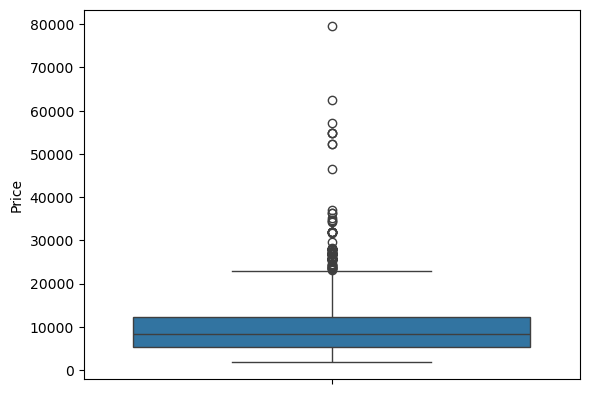

In [147]:

sns.boxplot(df['Price'])

# Bivariate Analysis
- 'Jet Airways Business' are paid highest prices(avg- 58358)
- As the Total_stops increases the flight avg. price are also increases.
- 'No information' status passegers Are more but they paid very low flight ticket(avg- 9059)
- If a flight is Business Class then it will highest flight price(avg- 54035)
- 120 to 180 mins travel duration flights have low flight price.

- 'Jet Airways Business' Airlines month are March only and 1 and 2 stops 
- Only one people traveled through 4 stops.
- Only 43 peoples are traveled through 3 stops.
- If we Exclude Aditional_Info of ['No info', 'No check-in baggage included', 'In-flight meal not included'] We get 36 rows and their mean flight price is 27223

- Source='Delhi',  'Kolkata' travel maximum with 1 stop, 'Banglore' Mostly with 0 stops
- March months Mostly Source is delhi and banglore
- Destination = Kolkata, Delhi, Hydrabad will likely to travel with 0 stops(99%)
- New delhi, Banglore, Cochin will likely to travel with 1 stops
- Peoples destination is new delhi 100% in march

In [148]:
df.shape

(10462, 13)

In [149]:
df.sample(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_in_min,Month_of_the_Journey
5576,Air India,2019-05-09,Delhi,Cochin,DEL → HYD → MAA → COK,2026-05-17 13:15:00,2026-05-10 09:25:00,20h 10m,2,No info,9417,1210,May
7009,Jet Airways,2019-03-18,Mumbai,Hyderabad,BOM → HYD,2026-05-17 02:55:00,2026-05-17 04:25:00,1h 30m,0,No info,5678,90,March
5220,SpiceJet,2019-05-03,Banglore,Delhi,BLR → DEL,2026-05-17 05:55:00,2026-05-17 08:35:00,2h 40m,0,No info,3625,160,May


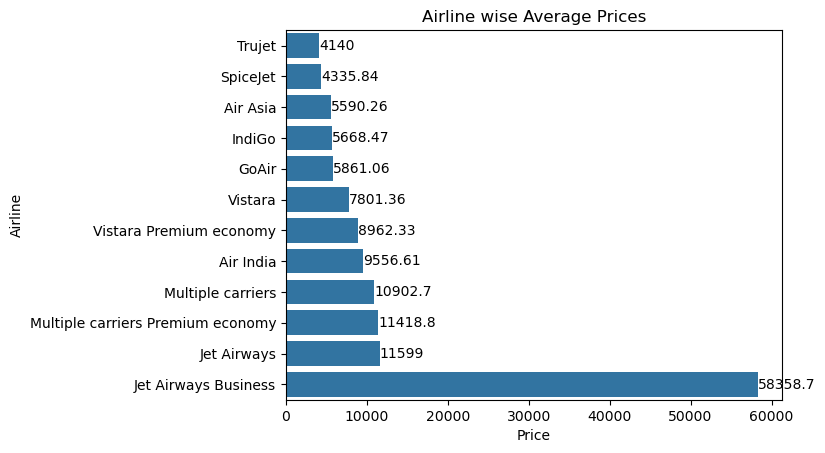

In [150]:
order = df.groupby('Airline')['Price'].mean().sort_values(ascending=True).index
ax = sns.barplot(y='Airline', x='Price', data=df, order=order, ci=None)
ax.bar_label(ax.containers[0])
plt.title("Airline wise Average Prices")
plt.show()

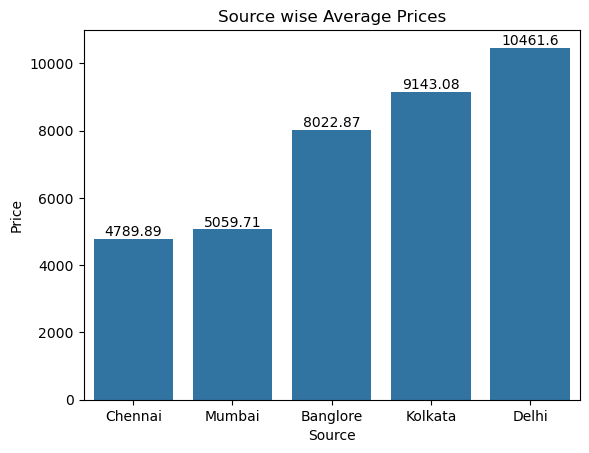

In [151]:
order = df.groupby('Source')['Price'].mean().sort_values(ascending=True).index
ax = sns.barplot(x='Source', y='Price', data=df, order=order, ci=None)
ax.bar_label(ax.containers[0])
plt.title("Source wise Average Prices")
plt.show()

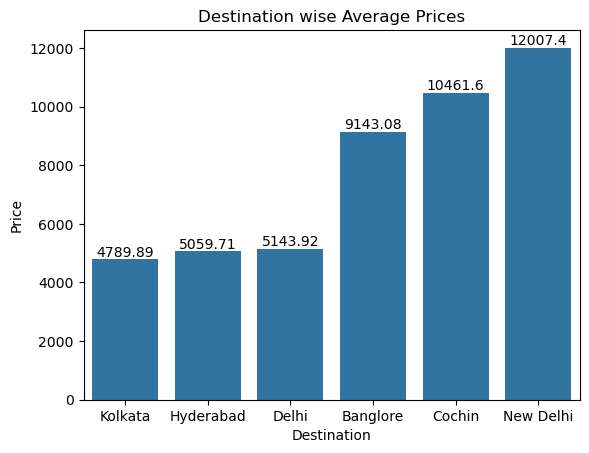

In [152]:
order = df.groupby('Destination')['Price'].mean().sort_values(ascending=True).index
ax = sns.barplot(x='Destination', y='Price', data=df, order=order, ci=None)
ax.bar_label(ax.containers[0])
plt.title("Destination wise Average Prices")
plt.show()

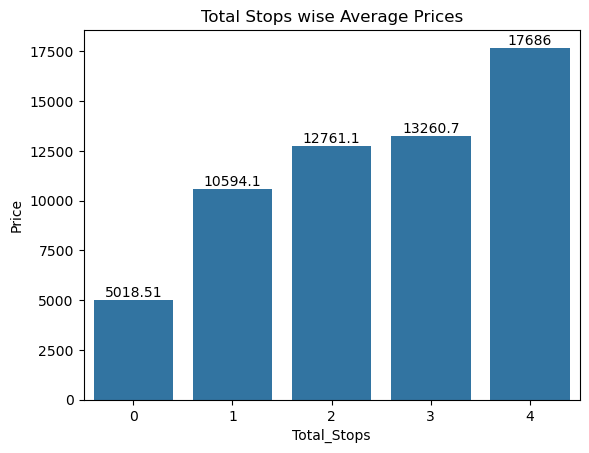

In [153]:
order = df.groupby('Total_Stops')['Price'].mean().sort_values(ascending=True).index
ax = sns.barplot(x='Total_Stops', y='Price', data=df, order=order, ci=None)
ax.bar_label(ax.containers[0])
plt.title("Total Stops wise Average Prices")
plt.show()

<Axes: xlabel='Total_Stops', ylabel='Price'>

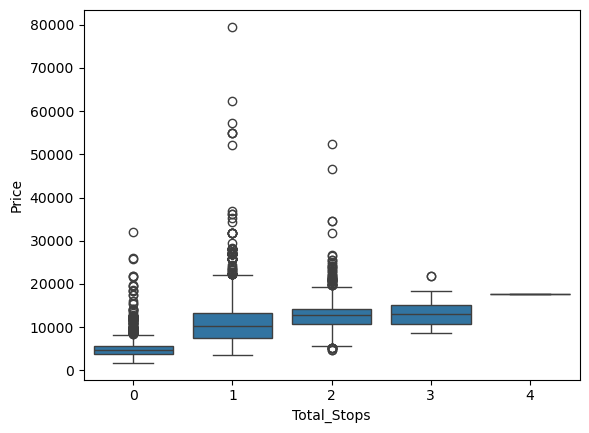

In [154]:
stop_order = ['0', '1', '2', '3', '4']
sns.boxplot(x='Total_Stops', y='Price', data=df, order=stop_order)


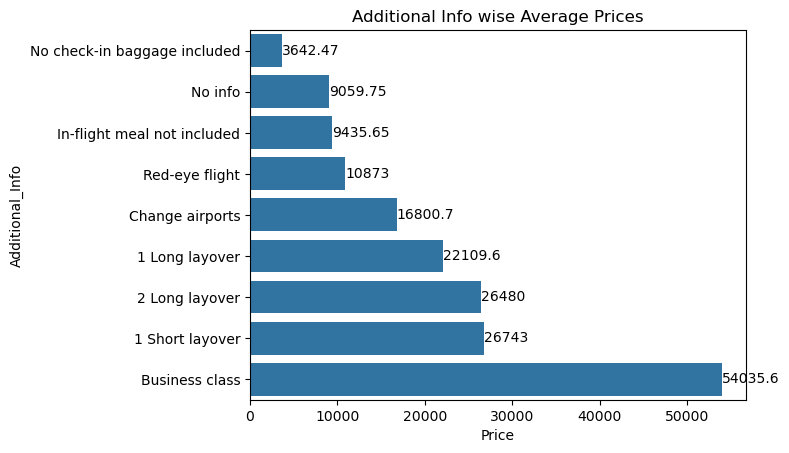

In [155]:
order = df.groupby('Additional_Info')['Price'].mean().sort_values(ascending=True).index
ax = sns.barplot(y='Additional_Info', x='Price', data=df, order=order, ci=None)
ax.bar_label(ax.containers[0])
plt.title("Additional Info wise Average Prices")
plt.show()

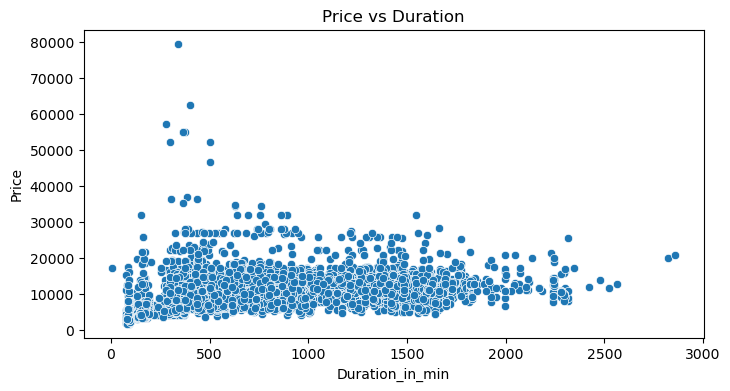

In [156]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Duration_in_min', y='Price')
plt.title("Price vs Duration")
plt.show()

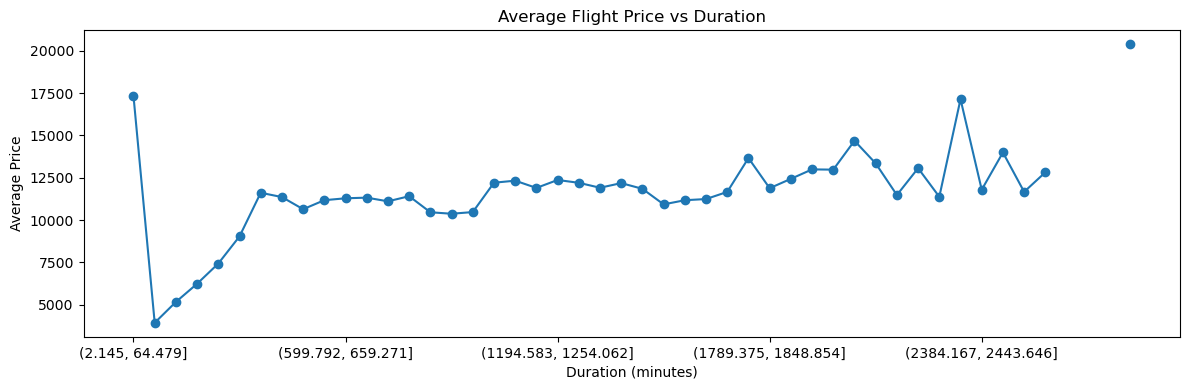

In [157]:
avg_price = df.groupby(
    pd.cut(df['Duration_in_min'], bins=48)
)['Price'].mean()

plt.figure(figsize=(12,4))
avg_price.plot(kind='line', marker='o')
plt.xlabel("Duration (minutes)")
plt.ylabel("Average Price")
plt.title("Average Flight Price vs Duration")
plt.tight_layout()
plt.show()

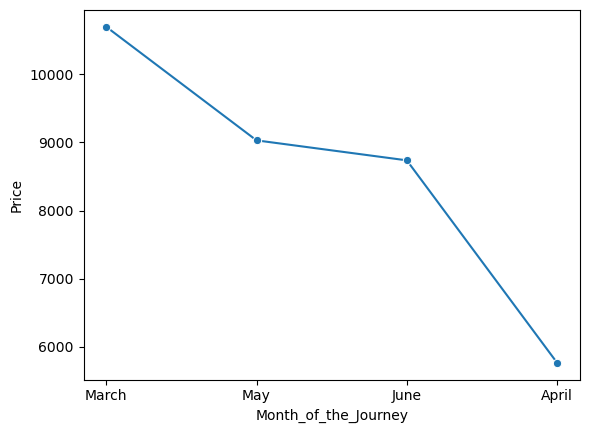

In [158]:
sns.lineplot(data=df, x='Month_of_the_Journey', y='Price', errorbar=None, marker='o')
plt.show()

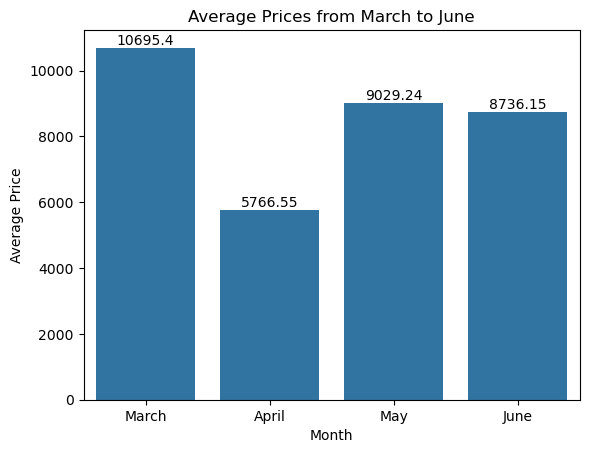

In [159]:
month_order = ['March', 'April', 'May', 'June']

ax = sns.barplot(x='Month_of_the_Journey', y='Price', data=df, order=month_order, errorbar=None)

ax.bar_label(ax.containers[0])
plt.title("Average Prices from March to June")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.show()

In [160]:
df[df['Month_of_the_Journey']=='May']['Price'].mean()

np.float64(9029.239764359352)

In [161]:
df.describe()[['Duration_in_min', 'Price']]

,Duration_in_min,Price
count,10462.000000,10462.000000
mean,629.781591,9026.790289
min,5.000000,1759.000000
25%,170.000000,5224.000000
50%,505.000000,8266.000000
75%,910.000000,12344.750000
max,2860.000000,79512.000000
std,500.699045,4624.849541


In [162]:
df[['Duration_in_min', 'Price', 'Total_Stops']].corr()

,Duration_in_min,Price,Total_Stops
Duration_in_min,1.000000,0.501758,0.727982
Price,0.501758,1.000000,0.602013
Total_Stops,0.727982,0.602013,1.000000


In [163]:
df['Additional_Info'].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Business class                     7
Change airports                    7
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [164]:
df.sample(4)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_in_min,Month_of_the_Journey
4549,Jet Airways,2019-04-03,Mumbai,Hyderabad,BOM → HYD,2026-05-17 07:05:00,2026-05-17 08:30:00,1h 25m,0,No info,8040,85,April
6062,Jet Airways,2019-03-21,Delhi,Cochin,DEL → BOM → COK,2026-05-17 02:15:00,2026-05-17 18:50:00,16h 35m,1,In-flight meal not included,7438,995,March
10286,Jet Airways,2019-06-27,Delhi,Cochin,DEL → BOM → COK,2026-05-17 14:00:00,2026-06-28 12:35:00,22h 35m,1,In-flight meal not included,10262,1355,June
218,Jet Airways,2019-05-12,Banglore,Delhi,BLR → DEL,2026-05-17 15:15:00,2026-05-17 18:10:00,2h 55m,0,No info,7229,175,May


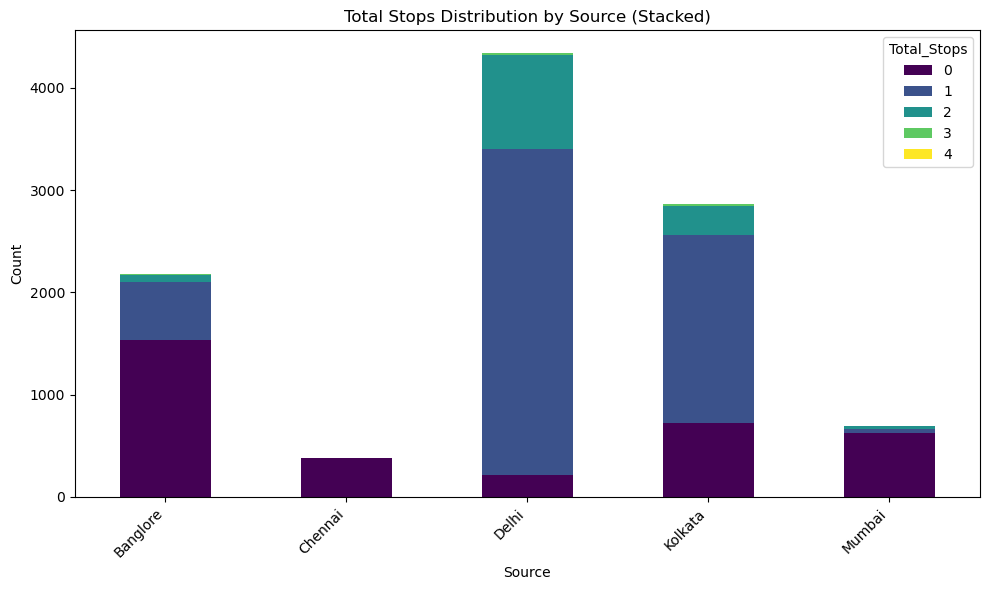

In [165]:
grouped_data = df.groupby(['Source', 'Total_Stops']).size().unstack(fill_value=0)
grouped_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Total Stops Distribution by Source (Stacked)')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total_Stops')
plt.tight_layout()
plt.show()

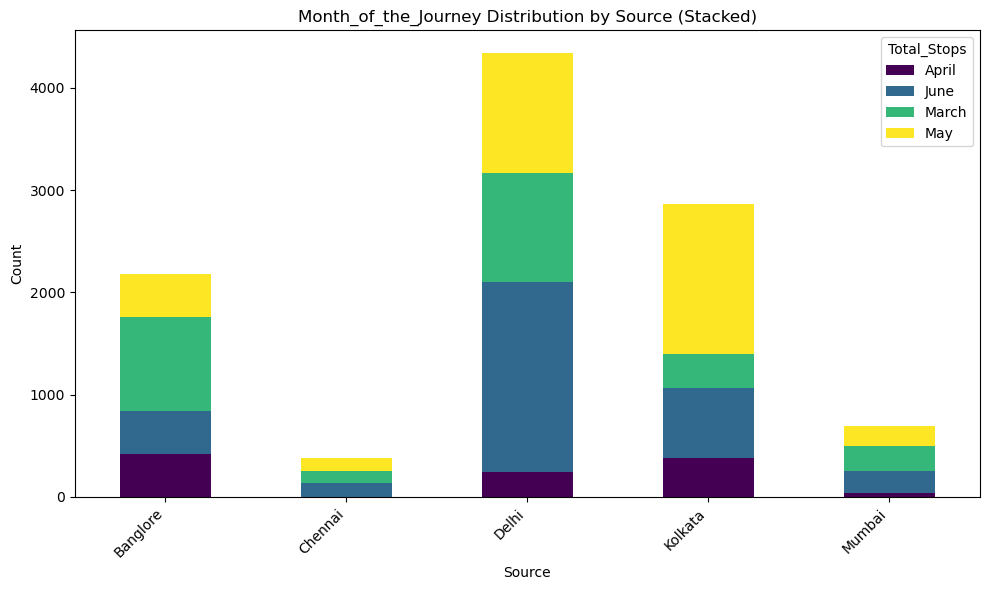

In [166]:
grouped_data = df.groupby(['Source', 'Month_of_the_Journey']).size().unstack(fill_value=0)
grouped_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Month_of_the_Journey Distribution by Source (Stacked)')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total_Stops')
plt.tight_layout()
plt.show()

In [167]:
df[df['Total_Stops']=='1']['Price'].mean()

np.float64(10594.123555555556)

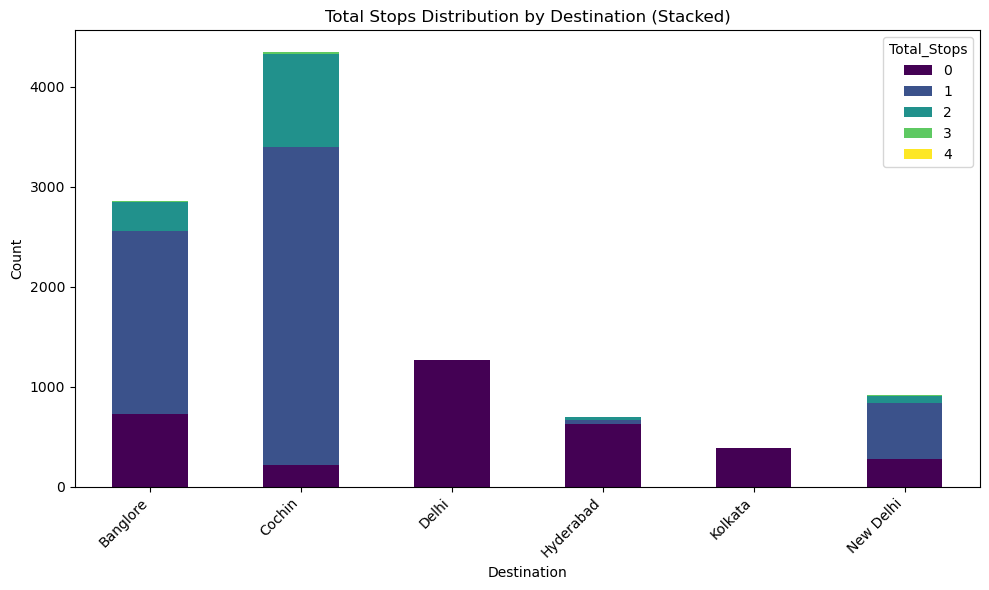

In [168]:
grouped_data = df.groupby(['Destination', 'Total_Stops']).size().unstack(fill_value=0)
grouped_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Total Stops Distribution by Destination (Stacked)')
plt.xlabel('Destination')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total_Stops')
plt.tight_layout()
plt.show()

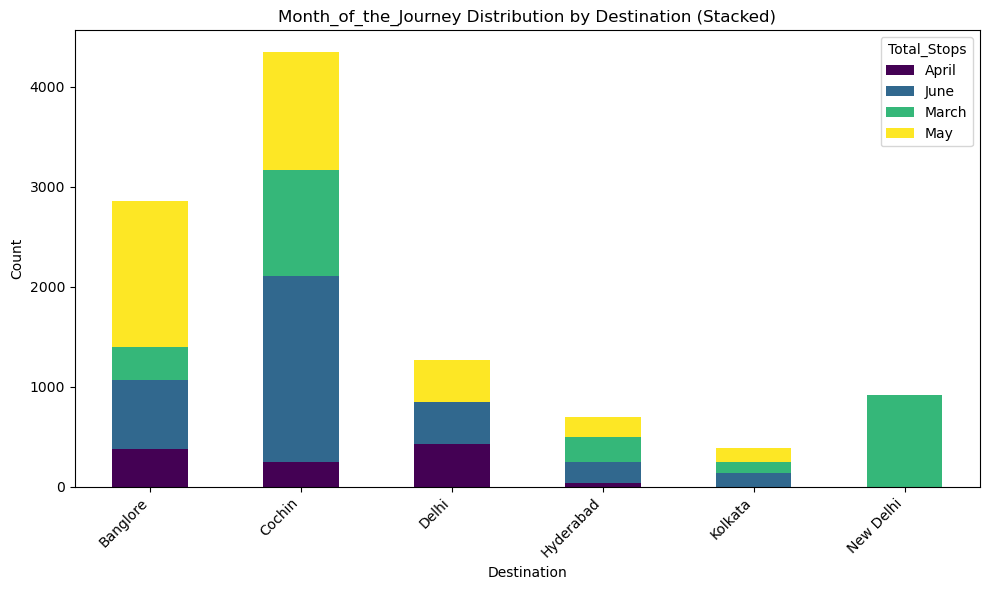

In [169]:
grouped_data = df.groupby(['Destination', 'Month_of_the_Journey']).size().unstack(fill_value=0)
grouped_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Month_of_the_Journey Distribution by Destination (Stacked)')
plt.xlabel('Destination')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Total_Stops')
plt.tight_layout()
plt.show()

In [170]:
pd.crosstab(df['Month_of_the_Journey'], df['Airline'], normalize='columns')*100

Airline,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
Month_of_the_Journey,,,,,,,,,,,,
April,18.181818,8.677686,22.680412,15.320607,7.297297,0.0,1.337793,0.0,19.141104,0.0,15.271967,33.333333
June,30.407524,27.626919,30.927835,29.907000,32.810811,0.0,42.140468,0.0,28.957055,0.0,25.313808,0.000000
March,18.808777,30.460449,20.618557,27.263828,23.756757,100.0,26.170569,100.0,21.595092,100.0,24.058577,66.666667
May,32.601881,33.234947,25.773196,27.508566,36.135135,0.0,30.351171,0.0,30.306748,0.0,35.355649,0.000000


<Axes: xlabel='Airline', ylabel='Month_of_the_Journey'>

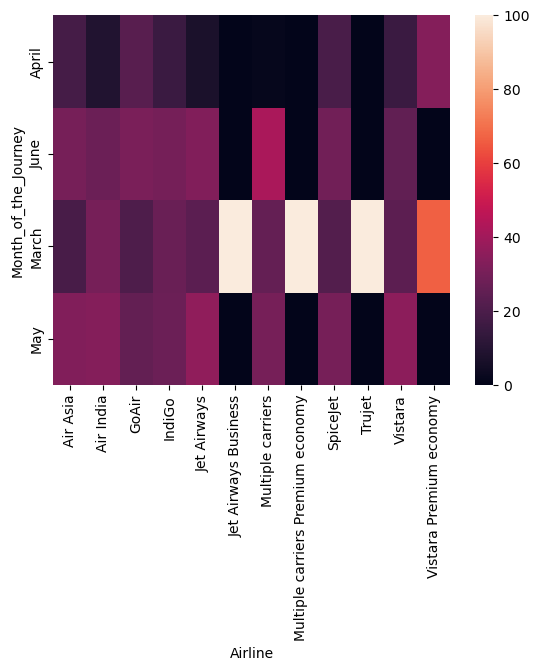

In [171]:
sns.heatmap(pd.crosstab(df['Month_of_the_Journey'], df['Airline'], normalize='columns')*100)

In [172]:
df[df['Duration_in_min'] == 5]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_in_min,Month_of_the_Journey
6474,Air India,2019-03-06,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,2026-05-17 16:50:00,2026-05-17 16:55:00,5m,2,No info,17327,5,March


# Model Training

In [173]:
X = df[['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info', 'Duration_in_min', 'Month_of_the_Journey']]
y = df['Price']

In [174]:
# IMPORTS
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score


# 1. OUTLIER REMOVAL (IQR METHOD)
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (y >= lower_bound) & (y <= upper_bound)

X = X[mask]
y = y[mask]

print("Shape after outlier removal:", X.shape)


# 2. COLUMN TYPES
nominal_cols = ['Airline', 'Source', 'Destination', 'Additional_Info']
ordinal_cols = ['Month_of_the_Journey']
numeric_cols = ['Total_Stops', 'Duration_in_min']


# 3. ORDINAL ENCODER (MONTH ORDER)
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

ordinal_encoder = OrdinalEncoder(categories=[month_order])


# 4. COLUMN TRANSFORMER
preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        ('ordinal', ordinal_encoder, ordinal_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


# 5. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# 6. MODEL
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# 7. PIPELINE
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])


# 8. TRAIN MODEL
pipeline.fit(X_train, y_train)


# 9. EVALUATION
y_pred = pipeline.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

Shape after outlier removal: (10368, 7)
R2 Score : 0.7969330773755519
MAE      : 1053.3663437636349
RMSE     : 1815.5688837910222
